## CESM2 hist2ts

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ['PATH'] = '/glade/u/apps/derecho/24.12/spack/opt/spack/nco/5.3.1/gcc/12.4.0/vih5/bin' + ':' + os.environ['PATH']
os.chdir('/glade/u/home/fengzhu/Github/x4c/docsrc/notebooks')
import numpy as np
import x4c
print(x4c.__version__)

2025.6.22


In [5]:
dirpath = os.path.join('/glade/campaign/cesm/development/cross-wg/diagnostic_framework/CESM_output_for_testing/b.e23_alpha17f.BLT1850.ne30_t232.092')
case = x4c.History(
    dirpath,
    casename='b.e23_alpha17f.BLT1850.ne30_t232.092',
    cesm_ver=2,
)

>>> case.root_dir: /glade/campaign/cesm/development/cross-wg/diagnostic_framework/CESM_output_for_testing/b.e23_alpha17f.BLT1850.ne30_t232.092
>>> case.casename: b.e23_alpha17f.BLT1850.ne30_t232.092
>>> case.comps_info: {'atm': ('cam', ['h0a', 'h0i']), 'ocn': ('mom6', ['h.sfc', 'h.z', 'h.native', 'h.rho2']), 'lnd': ('clm2', 'h0'), 'ice': ('cice', 'h'), 'rof': ('mosart', 'h0')}
>>> case.paths["atm"] created
>>> case.paths["ocn"] created
>>> case.paths["lnd"] created
>>> case.paths["ice"] created
>>> case.paths["rof"] created
>>> case.vns["atm"] created
>>> case.vns["ocn"] created
>>> case.vns["lnd"] created
>>> case.vns["ice"] created
>>> case.vns["rof"] created


In [6]:
case.paths['ocn']

['/glade/campaign/cesm/development/cross-wg/diagnostic_framework/CESM_output_for_testing/b.e23_alpha17f.BLT1850.ne30_t232.092/ocn/hist/b.e23_alpha17f.BLT1850.ne30_t232.092.mom6.h.sfc.0001-01.nc',
 '/glade/campaign/cesm/development/cross-wg/diagnostic_framework/CESM_output_for_testing/b.e23_alpha17f.BLT1850.ne30_t232.092/ocn/hist/b.e23_alpha17f.BLT1850.ne30_t232.092.mom6.h.z.0001-01.nc',
 '/glade/campaign/cesm/development/cross-wg/diagnostic_framework/CESM_output_for_testing/b.e23_alpha17f.BLT1850.ne30_t232.092/ocn/hist/b.e23_alpha17f.BLT1850.ne30_t232.092.mom6.h.native.0001-01.nc',
 '/glade/campaign/cesm/development/cross-wg/diagnostic_framework/CESM_output_for_testing/b.e23_alpha17f.BLT1850.ne30_t232.092/ocn/hist/b.e23_alpha17f.BLT1850.ne30_t232.092.mom6.h.rho2.0001-01.nc',
 '/glade/campaign/cesm/development/cross-wg/diagnostic_framework/CESM_output_for_testing/b.e23_alpha17f.BLT1850.ne30_t232.092/ocn/hist/b.e23_alpha17f.BLT1850.ne30_t232.092.mom6.h.sfc.0001-02.nc',
 '/glade/campaign/

## atm

In [31]:
ds = x4c.open_dataset(case.paths['atm'][0])
ds

<xarray.Dataset> Size: 2GB
Dimensions:           (ncol: 48600, lev: 58, ilev: 59, trop_cld_lev: 58,
                       time: 1, nbnd: 2)
Coordinates:
  * lev               (lev) float64 464B 3.018 5.445 9.087 ... 983.2 991.2 997.5
  * ilev              (ilev) float64 472B 2.055 3.98 6.909 ... 987.4 995.1 1e+03
  * trop_cld_lev      (trop_cld_lev) float64 464B 3.018 5.445 ... 991.2 997.5
  * time              (time) object 8B 0001-01-16 12:00:00
Dimensions without coordinates: ncol, nbnd
Data variables: (12/367)
    lat               (ncol) float64 389kB ...
    lon               (ncol) float64 389kB ...
    areawt            (ncol) float64 389kB ...
    area              (ncol) float64 389kB ...
    hyam              (lev) float64 464B ...
    hybm              (lev) float64 464B ...
    ...                ...
    RTP2_CLUBB        (time, ilev, ncol) float32 11MB ...
    THLP2_CLUBB       (time, ilev, ncol) float32 11MB ...
    RTPTHLP_CLUBB     (time, ilev, ncol) float32 11MB ...
    WPRCP_CLUBB       (time, ilev, ncol) float32 11MB ...
    WPTHVP_CLUBB      (time, ilev, ncol) float32 11MB ...
    ZM_CLUBB          (time, ilev, ncol) float32 11MB ...
Attributes:
    ne:                30
    fv_nphys:          3
    Conventions:       CF-1.0
    source:            CAM
    case:              b.e23_alpha17f.BLT1850.ne30_t232.092
    logname:           gmarques
    host:              dec1824
    initial_file:      /glade/campaign/cesm/cesmdata/inputdata/atm/cam/inic/s...
    topography_file:   /glade/campaign/cesm/cesmdata/inputdata/atm/cam/topo/s...
    model_doi_url:     not_set
    time_period_freq:  month_1
    path:              /glade/campaign/cesm/development/cross-wg/diagnostic_f...

In [7]:
%%time

case.gen_ts(
    # comps=['atm'],
    comps={'atm': ['TS']},
    output_dirpath=os.path.join('/glade/campaign/cgd/ppc/fengzhu/CESM_output/timeseries', case.casename),
    scratch_dirpath=os.path.join('/glade/derecho/scratch/fengzhu/x4c/gen_ts/test', case.casename),
    timespan=(1, 20),
    timestep=20,
    nproc=1,
    overwrite=True,
)

>>> Processing component: atm
>>> Processing timespan: (1, 20)


Merging variables: 100%|██████████| 1/1 [00:01<00:00,  1.82s/it]


>>> Postprocessing component: atm
>>> Postprocessing timespan: (1, 20)


Moving generated files
from: /glade/derecho/scratch/fengzhu/x4c/gen_ts/test/b.e23_alpha17f.BLT1850.ne30_t232.092
to: /glade/campaign/cgd/ppc/fengzhu/CESM_output/timeseries/b.e23_alpha17f.BLT1850.ne30_t232.092
Moving generated files [00:00<?, ?it/s]
from: /glade/derecho/scratch/fengzhu/x4c/gen_ts/test/b.e23_alpha17f.BLT1850.ne30_t232.092
to: /glade/campaign/cgd/ppc/fengzhu/CESM_output/timeseries/b.e23_alpha17f.BLT1850.ne30_t232.092
: 100%|██████████| 1/1 [00:00<00:00, 452.22it/s]

CPU times: user 334 ms, sys: 213 ms, total: 548 ms
Wall time: 55.9 s


In [32]:
ds = x4c.open_dataset(
    '/glade/campaign/cgd/ppc/fengzhu/CESM_output/timeseries/b.e23_alpha17f.BLT1850.ne30_t232.092/atm/proc/tseries/month_1/b.e23_alpha17f.BLT1850.ne30_t232.092.cam.h0a.TS.000101-002012.nc',
)
ds

<xarray.Dataset> Size: 48MB
Dimensions:       (time: 240, ncol: 48600, ilev: 59, lev: 58, nbnd: 2,
                   trop_cld_lev: 58)
Coordinates:
  * ilev          (ilev) float64 472B 2.055 3.98 6.909 ... 987.4 995.1 1e+03
  * lev           (lev) float64 464B 3.018 5.445 9.087 ... 983.2 991.2 997.5
  * time          (time) object 2kB 0001-01-16 12:00:00 ... 0020-12-16 12:00:00
  * trop_cld_lev  (trop_cld_lev) float64 464B 3.018 5.445 9.087 ... 991.2 997.5
Dimensions without coordinates: ncol, nbnd
Data variables: (12/19)
    TS            (time, ncol) float32 47MB ...
    area          (ncol) float64 389kB ...
    areawt        (ncol) float64 389kB ...
    date          (time) int32 960B ...
    date_written  (time) |S8 2kB ...
    datesec       (time) int32 960B ...
    ...            ...
    nbdate        int32 4B ...
    nbsec         int32 4B ...
    ndbase        int32 4B ...
    nsbase        int32 4B ...
    time_bounds   (time, nbnd) object 4kB ...
    time_written  (time) |S8 2kB ...
Attributes:
    ne:                30
    fv_nphys:          3
    Conventions:       CF-1.0
    source:            CAM
    case:              b.e23_alpha17f.BLT1850.ne30_t232.092
    logname:           gmarques
    host:              dec1824
    initial_file:      /glade/campaign/cesm/cesmdata/inputdata/atm/cam/inic/s...
    topography_file:   /glade/campaign/cesm/cesmdata/inputdata/atm/cam/topo/s...
    model_doi_url:     not_set
    time_period_freq:  month_1
    path:              /glade/campaign/cgd/ppc/fengzhu/CESM_output/timeseries...

In [33]:
ds['TS']

<xarray.DataArray 'TS' (time: 240, ncol: 48600)> Size: 47MB
[11664000 values with dtype=float32]
Coordinates:
  * time     (time) object 2kB 0001-01-16 12:00:00 ... 0020-12-16 12:00:00
Dimensions without coordinates: ncol
Attributes:
    units:         K
    long_name:     Surface temperature (radiative)
    cell_methods:  time: mean

In [40]:
da = ds['TS'].x.annualize() - 273.15
da['lat'] = ds['lat']
da['lon'] = ds['lon']
da.attrs['units'] = '°C'
da.attrs['comp'] = 'atm'
da.attrs['grid'] = 'ne30pg3'
da

<xarray.DataArray 'TS' (time: 20, ncol: 48600)> Size: 4MB
array([[19.523193, 19.268494, 18.997955, ..., 17.24353 , 19.13031 ,
        19.990051],
       [19.622345, 19.284668, 18.944275, ..., 17.982086, 19.844727,
        20.631897],
       [19.984741, 19.623688, 19.263184, ..., 18.461487, 20.30188 ,
        21.16983 ],
       ...,
       [18.627136, 18.248718, 17.937256, ..., 17.426819, 19.077911,
        19.869019],
       [18.872833, 18.499298, 18.103363, ..., 17.130432, 18.861023,
        19.77417 ],
       [18.757324, 18.301819, 17.85672 , ..., 17.6315  , 19.31195 ,
        20.131287]], dtype=float32)
Coordinates:
  * time     (time) object 160B 0001-12-31 00:00:00 ... 0020-12-31 00:00:00
    lat      (ncol) float64 389kB ...
    lon      (ncol) float64 389kB ...
Dimensions without coordinates: ncol
Attributes:
    units:         °C
    long_name:     Surface temperature (radiative)
    cell_methods:  time: mean
    comp:          atm
    grid:          ne30pg3

CPU times: user 1.06 s, sys: 4.92 ms, total: 1.06 s
Wall time: 1.06 s


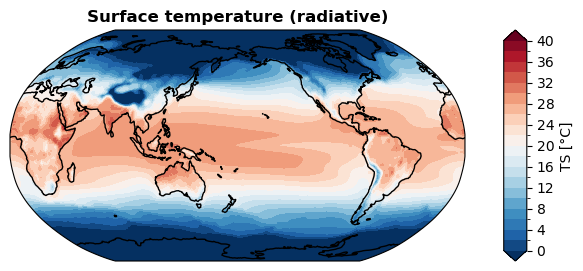

In [50]:
%%time
fig, ax = da.mean('time').x.regrid().x.plot(
    levels=np.linspace(0, 40, 21),
    cbar_kwargs={'ticks': np.linspace(0, 40, 11)},
)

CPU times: user 264 ms, sys: 309 μs, total: 264 ms
Wall time: 263 ms


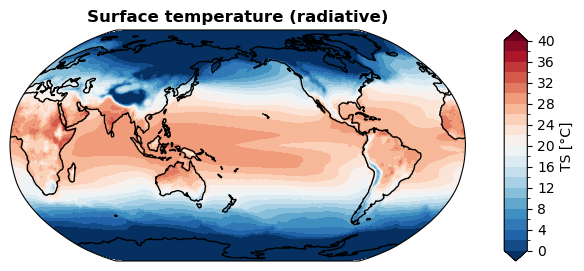

In [51]:
%%time
fig, ax = da.mean('time').x.plot(
    levels=np.linspace(0, 40, 21),
    cbar_kwargs={'ticks': np.linspace(0, 40, 11)},
)

Fetching data: 100%|██████████| 1.01M/1.01M [00:00<00:00, 66.8MiB/s]


CPU times: user 1.31 s, sys: 75.8 ms, total: 1.38 s
Wall time: 4.32 s


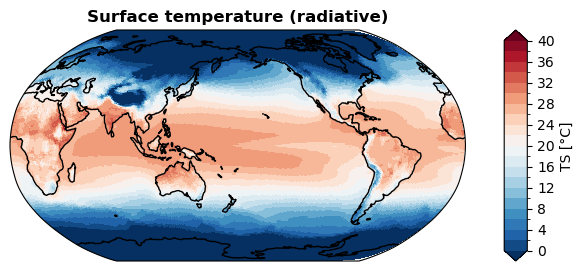

In [52]:
%%time
fig, ax = da.mean('time').x.plot(
    levels=np.linspace(0, 40, 21),
    cbar_kwargs={'ticks': np.linspace(0, 40, 11)},
    ux=True,
)

## ocn

In [56]:
ds = x4c.open_dataset(case.paths['ocn'][0])
ds

<xarray.Dataset> Size: 2GB
Dimensions:               (scalar_axis: 1, time: 1, nbnd: 2, xq: 540, yh: 480,
                           zl: 75, xh: 540, yq: 480, zi: 76)
Coordinates:
  * scalar_axis           (scalar_axis) float64 8B 0.0
  * time                  (time) object 8B 0001-01-16 12:00:00
  * nbnd                  (nbnd) float64 16B 1.0 2.0
  * xq                    (xq) float64 4kB -286.3 -285.7 -285.0 ... 72.33 73.0
  * yh                    (yh) float64 4kB -81.56 -81.46 -81.36 ... 87.71 87.74
  * zl                    (zl) float64 600B 1.25 3.75 ... 4.58e+03 5.506e+03
  * xh                    (xh) float64 4kB -286.7 -286.0 -285.3 ... 72.0 72.67
  * yq                    (yq) float64 4kB -81.51 -81.41 -81.31 ... 87.73 87.74
  * zi                    (zi) float64 608B 0.0 2.5 5.0 ... 5.012e+03 6e+03
Data variables: (12/76)
    soga                  (time, scalar_axis) float32 4B ...
    thetaoga              (time, scalar_axis) float32 4B ...
    uh                    (time, zl, yh, xq) float32 78MB ...
    vh                    (time, zl, yq, xh) float32 78MB ...
    vhbt                  (time, yq, xh) float32 1MB ...
    uhbt                  (time, yh, xq) float32 1MB ...
    ...                    ...
    speed                 (time, yh, xh) float32 1MB ...
    mlotst                (time, yh, xh) float32 1MB ...
    average_T1            (time) object 8B ...
    average_T2            (time) object 8B ...
    average_DT            (time) timedelta64[ns] 8B ...
    time_bounds           (time, nbnd) object 16B ...
Attributes:
    NumFilesInSet:     1
    title:             MOM6 diagnostic fields table for CESM case: b.e23_alph...
    associated_files:  areacello: b.e23_alpha17f.BLT1850.ne30_t232.092.mom6.h...
    grid_type:         regular
    grid_tile:         N/A
    path:              /glade/campaign/cesm/development/cross-wg/diagnostic_f...

In [53]:
case.gen_ts(
    # comps=['ocn'],
    comps={'ocn': ['tos']},
    output_dirpath=os.path.join('/glade/campaign/cgd/ppc/fengzhu/CESM_output/timeseries', case.casename),
    scratch_dirpath=os.path.join('/glade/derecho/scratch/fengzhu/x4c/gen_ts/test', case.casename),
    timespan=(1, 20),
    timestep=20,
    nproc=1,
    overwrite=True,
)

>>> Processing component: ocn
>>> Processing timespan: (1, 20)


Merging variables: 100%|██████████| 1/1 [00:03<00:00,  3.79s/it]


>>> Postprocessing component: ocn
>>> Postprocessing timespan: (1, 20)


Moving generated files
from: /glade/derecho/scratch/fengzhu/x4c/gen_ts/test/b.e23_alpha17f.BLT1850.ne30_t232.092
to: /glade/campaign/cgd/ppc/fengzhu/CESM_output/timeseries/b.e23_alpha17f.BLT1850.ne30_t232.092
Moving generated files [00:00<?, ?it/s]
from: /glade/derecho/scratch/fengzhu/x4c/gen_ts/test/b.e23_alpha17f.BLT1850.ne30_t232.092
to: /glade/campaign/cgd/ppc/fengzhu/CESM_output/timeseries/b.e23_alpha17f.BLT1850.ne30_t232.092
: 100%|██████████| 1/1 [00:00<00:00, 522.52it/s]


In [54]:
ds = x4c.open_dataset(
    '/glade/campaign/cgd/ppc/fengzhu/CESM_output/timeseries/b.e23_alpha17f.BLT1850.ne30_t232.092/ocn/proc/tseries/month_1/b.e23_alpha17f.BLT1850.ne30_t232.092.h.native.tos.000101-002012.nc',
)
ds

<xarray.Dataset> Size: 249MB
Dimensions:      (time: 240, nbnd: 2, scalar_axis: 1, yh: 480, xh: 540,
                  xq: 540, yq: 480, zi: 76, zl: 75)
Coordinates:
  * nbnd         (nbnd) float64 16B 1.0 2.0
  * scalar_axis  (scalar_axis) float64 8B 0.0
  * time         (time) object 2kB 0001-01-16 12:00:00 ... 0020-12-16 12:00:00
  * xh           (xh) float64 4kB -286.7 -286.0 -285.3 ... 71.33 72.0 72.67
  * xq           (xq) float64 4kB -286.3 -285.7 -285.0 ... 71.67 72.33 73.0
  * yh           (yh) float64 4kB -81.56 -81.46 -81.36 ... 87.65 87.71 87.74
  * yq           (yq) float64 4kB -81.51 -81.41 -81.31 ... 87.68 87.73 87.74
  * zi           (zi) float64 608B 0.0 2.5 5.0 7.5 ... 4.149e+03 5.012e+03 6e+03
  * zl           (zl) float64 600B 1.25 3.75 6.25 ... 4.58e+03 5.506e+03
Data variables:
    average_DT   (time) timedelta64[ns] 2kB ...
    average_T1   (time) object 2kB ...
    average_T2   (time) object 2kB ...
    time_bounds  (time, nbnd) object 4kB ...
    tos          (time, yh, xh) float32 249MB ...
Attributes:
    NumFilesInSet:     1
    title:             MOM6 diagnostic fields table for CESM case: b.e23_alph...
    associated_files:  areacello: b.e23_alpha17f.BLT1850.ne30_t232.092.mom6.h...
    grid_type:         regular
    grid_tile:         N/A
    path:              /glade/campaign/cgd/ppc/fengzhu/CESM_output/timeseries...

In [57]:
da = ds['tos'].x.annualize()
da.attrs['units'] = '°C'
da.attrs['comp'] = 'ocn'
da.attrs['grid'] = 't232'
da

<xarray.DataArray 'tos' (time: 1, yh: 480, xh: 540)> Size: 1MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
  * yh       (yh) float64 4kB -81.56 -81.46 -81.36 -81.26 ... 87.65 87.71 87.74
  * xh       (xh) float64 4kB -286.7 -286.0 -285.3 -284.7 ... 71.33 72.0 72.67
  * time     (time) object 8B 0001-12-31 00:00:00
Attributes:
    units:          °C
    long_name:      Sea Surface Temperature
    cell_methods:   area:mean yh:mean xh:mean time: mean
    cell_measures:  area: areacello
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  sea_surface_temperature
    comp:           ocn
    grid:           t232

In [58]:
%%time
fig, ax = da.mean('time').x.regrid().x.plot(
    levels=np.linspace(0, 40, 21),
    cbar_kwargs={'ticks': np.linspace(0, 40, 11)},
)

AttributeError: 'Dataset' object has no attribute 'TLAT'